In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex

from scipy.interpolate import CubicSpline
from few import get_file_manager
import tqdm

# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux_nex, use_gpu=True)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

from cycler import cycler

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#373E8E",  # black
    "#b4af1f",  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
])

from mpl_toolkits.axes_grid1 import make_axes_locatable

def inner_product(x, y, psd):
    return 4 * np.real(np.sum(np.conj(x) * y / psd))#

In [2]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

def wf_gen(n,e0,T,p0=None,a=None):


        # define the injection parameters
    m1 = 1e6  # central object mass (solar masses)
    if a == None:
        a = 1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
    else:
        a=a
        print(a)
    m2 = 10.0  
    p0 = p0  
    e0 = e0  

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)

    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    Tobs = T   
    if T>0.5:         
        dt = 1    
    elif T<1/365:
        dt=0.1
    else:
        dt=1   


    mode_selection_threshold = 1e-5




    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }

   
    if p0 is None:
        p0 = get_p_at_t(
            traj_module,
            Tobs*0.99999,
            [m1, m2, a, e0, 1.0],       
            index_of_p=3,               
            index_of_a=2,               
            index_of_e=4,               
            index_of_x=5,
            traj_kwargs={},
            xtol=2e-12,                 
            rtol=8.881784197001252e-16, 
            bounds=None,
        )
        print("New p0: ", p0)



    emri_injection_params = [
        m1,
        m2,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
    ]


    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) 
    time_array = np.arange(0, len(data_channels_td[0])) * dt

    return [time_array, data_channels_td,p0]

def stencil(a,e,p,da):
    # define the intrinsic parameters that need to be changed
    m1 = 1e6  # central object mass in solar masses
    m2 = 10.0  # secondary object mass in solar masses
    p0 = p  # initial semi-latus rectum
    e0 = e  # eccentricity
    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_r0 = np.pi / 3
    dist = 1.0  # distance in Gpc
    a0 = a

    x0 = 1.0  # will be ignored in Schwarzschild waveform
    Phi_theta0 = 0.0

    # define the extrinsic parameters
    qK = np.pi / 3  # polar spin angle
    phiK = np.pi / 3  # azimuthal viewing angle
    qS = np.pi / 3  # polar sky angle
    phiS = np.pi / 3  # azimuthal viewing angle
    dist = 1.0  # distance in Gpc

    Tobs = 0.4  # observation time, if the inspiral is shorter, the it will be zero padded
    dt = 5.0  # time interval
    eps = 1e-2  # mode content percentage


    a0 = a
    ap2 = a0 + 2*da
    ap1 = a0 + da
    an1 = a0 - da
    an2 = a0 - 2*da

    waveform_kwargs = {"T": Tobs,"dt": dt,"mode_selection_threshold": eps}

    parametersap2 = [m1, m2, ap2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersap1 = [m1, m2, ap1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan2 = [m1, m2, an2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan1 = [m1, m2, an1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

    han2 = td_gen(*parametersan2, **waveform_kwargs)[0]
    hap1 = td_gen(*parametersap1, **waveform_kwargs)[0]
    han1 = td_gen(*parametersan1, **waveform_kwargs)[0]
    hap2 = td_gen(*parametersap2, **waveform_kwargs)[0]

    num = -hap2 + 8*hap1 - 8*han1 + han2
    den = 12*da

    derivitave = num/den

    time = np.arange(len(han1)) * dt

    

    return [han2,han1,hap2,hap1] , time,derivitave

###  Generalise the above function

In [12]:
#Need to calculate diffs for 


def stencil(param, a,e0, dparam = None):  #dparam = param*dn, unless param is a, then dparam=(1-a)*dn


    m1 = 1e6  
    m2 = 10.0  
    a=a
    e0 = e0 
    dist = 1.0       # luminosity distance (Gpc)

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle


    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_r0 = np.pi / 3

    Tobs = 1 #1 year

    p0 = get_p_at_t(
        traj_module,
        Tobs*0.99999,
        [m1, m2, a, e0, 1.0],       
        index_of_p=3,               
        index_of_a=2,               
        index_of_e=4,               
        index_of_x=5,
        traj_kwargs={},
        xtol=1e-8,                 
        rtol=1e-8, 
        bounds=None,
    )

    # Base parameters
    params = {
        "m1": m1,
        "m2": m2,
        "a": a,
        "p": p0,
        "e": e0,
        "x0": 1.0,
        "dist": dist,
        "phiK": np.pi/3,
        "qS": qS,
        "qK":qK,
        "phiS": phiS,
        "Phi_phi0": Phi_phi0,
        "Phi_theta0": 0.0,
        "Phi_r0": Phi_r0
    }

    Dparams = {
        "m1": 1e-9,
        "m2": 1e-8,
        "a": 5e-3,
        "p": 1e-8,
        "e": 1e-5,
        "x0": np.nan,
        "dist": 5e-3,
        "phiK": np.nan,
        "qS": np.nan,
        "qK":np.nan,
        "phiS": np.nan,
        "Phi_phi0": 1e-2,
        "Phi_theta0": np.nan,
        "Phi_r0": 1e-2
    }


   # Dparams =[0.0005,1e-08,1e-05,1e-09,1e-08,0.0005,0.01,0.01]   #delta_x = x*Delta


    # Perturbed values
    params_p2 = params.copy()
    params_p1 = params.copy()
    params_m1 = params.copy()
    params_m2 = params.copy()



    if dparam == None:

        if param=="a":
            dparam = (1-a)*Dparams[param]
        else:
            dparam = params[param]*Dparams[param]

    else:
        if param=="a":
            dparam = (1-a)*dparam
        else:
            dparam = params[param]*dparam

   # if e0 ==0:
   #     Dparams[Parameters.index(param)]*=0


    params_p2[param] += 2*dparam
    params_p1[param] += dparam
    params_m1[param] -= dparam
    params_m2[param] -= 2*dparam


    waveform_kwargs = {
        "T": Tobs,
        "dt": 50.0,
        "mode_selection_threshold": 1e-3
    }


    def generate(par):
        arguments = [
            par["m1"],
            par["m2"],
            par["a"],
            par["p"],
            par["e"],
            par["x0"],
            par["dist"],
            par["qS"],
            par["phiS"],
            par["qK"],
            par["phiK"],
            par["Phi_phi0"],
            par["Phi_theta0"],
            par["Phi_r0"]
        ]

        return td_gen(*arguments, **waveform_kwargs)[0]



    # Generate waveforms
    hm2 = generate(params_m2)
    hm1 = generate(params_m1)
    hp1 = generate(params_p1)
    hp2 = generate(params_p2)


    # 5-point derivative
    derivative = (
        -hp2
        + 8*hp1
        - 8*hm1
        + hm2
    )/(12*dparam)


    time = np.arange(len(derivative))*waveform_kwargs["dt"]

    return time, derivative

In [11]:
Dparams = {
    "m1": 1e-9,
    "m2": 1e-8,
    "a": 5e-3,
    "p": 1e-8,
    "e": 1e-5,
    "x0": np.nan,
    "dist": 5e-3,
    "phiK": np.nan,
    "qS": np.nan,
    "qK":np.nan,
    "phiS": np.nan,
    "Phi_phi0": 1e-2,
    "Phi_theta0": np.nan,
    "Phi_r0": 1e-2
}

Dparams["m1"]

1e-09

5.000000000000005e-06
4.999999999999449e-07
4.999999999977245e-08


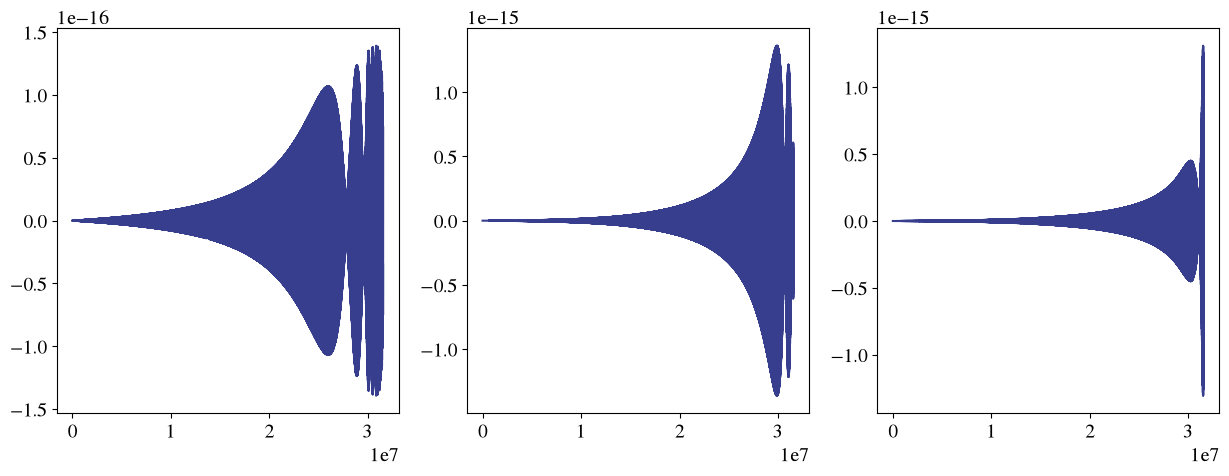

In [26]:
n_vals = [3,4,5]


fig,axs = plt.subplots(1,len(n_vals),figsize=(5*len(n_vals),5))

for i,n in enumerate(n_vals):

    t,da = stencil("a",1 - 10**(-n),0.2)

    axs[i].plot(t,da)
    #axs[i].set_xlim(0,3.1e7)

### Check what $\Delta$ wokrs best by evaluating $\partial_{param}h$

In [4]:
Parameters = ["a",  "p","e","m1","m2","dist","Phi_phi0","Phi_r0"]
#Parameters = ["m1","m1","dist"]
derivs = []
steps = [1e-1, 1e-2  , 1e-3, 1e-4, 1e-5,1e-6, 1e-7, 1e-8,1e-9]

all_derivsa = []
all_errorsa = []

for param in tqdm.tqdm(Parameters):

    derivs = []

    for h in steps:
        _,  d = stencil(param, 1 - 10**(-4),0.1, h )
        derivs.append(d)

    all_derivsa.append(derivs)

100%|██████████| 8/8 [08:07<00:00, 60.96s/it]


In [5]:
all_errors = []
for derivs in all_derivsa:
    errors = []

    for d1, d2 in zip(derivs[:-1], derivs[1:]):
        rel = np.linalg.norm(d2 - d1) / np.linalg.norm(d2)
        errors.append(rel)
    all_errors.append(errors)


In [50]:
all_errorsss = []

for derivs in all_derivsa:

    errors = []

    for d1, d2 in zip(derivs[:-1], derivs[1:]):
        rel = np.linalg.norm(d2 - d1) / np.linalg.norm(d2)
        errors.append(rel)

    all_errorsss.append(errors)



[0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08]


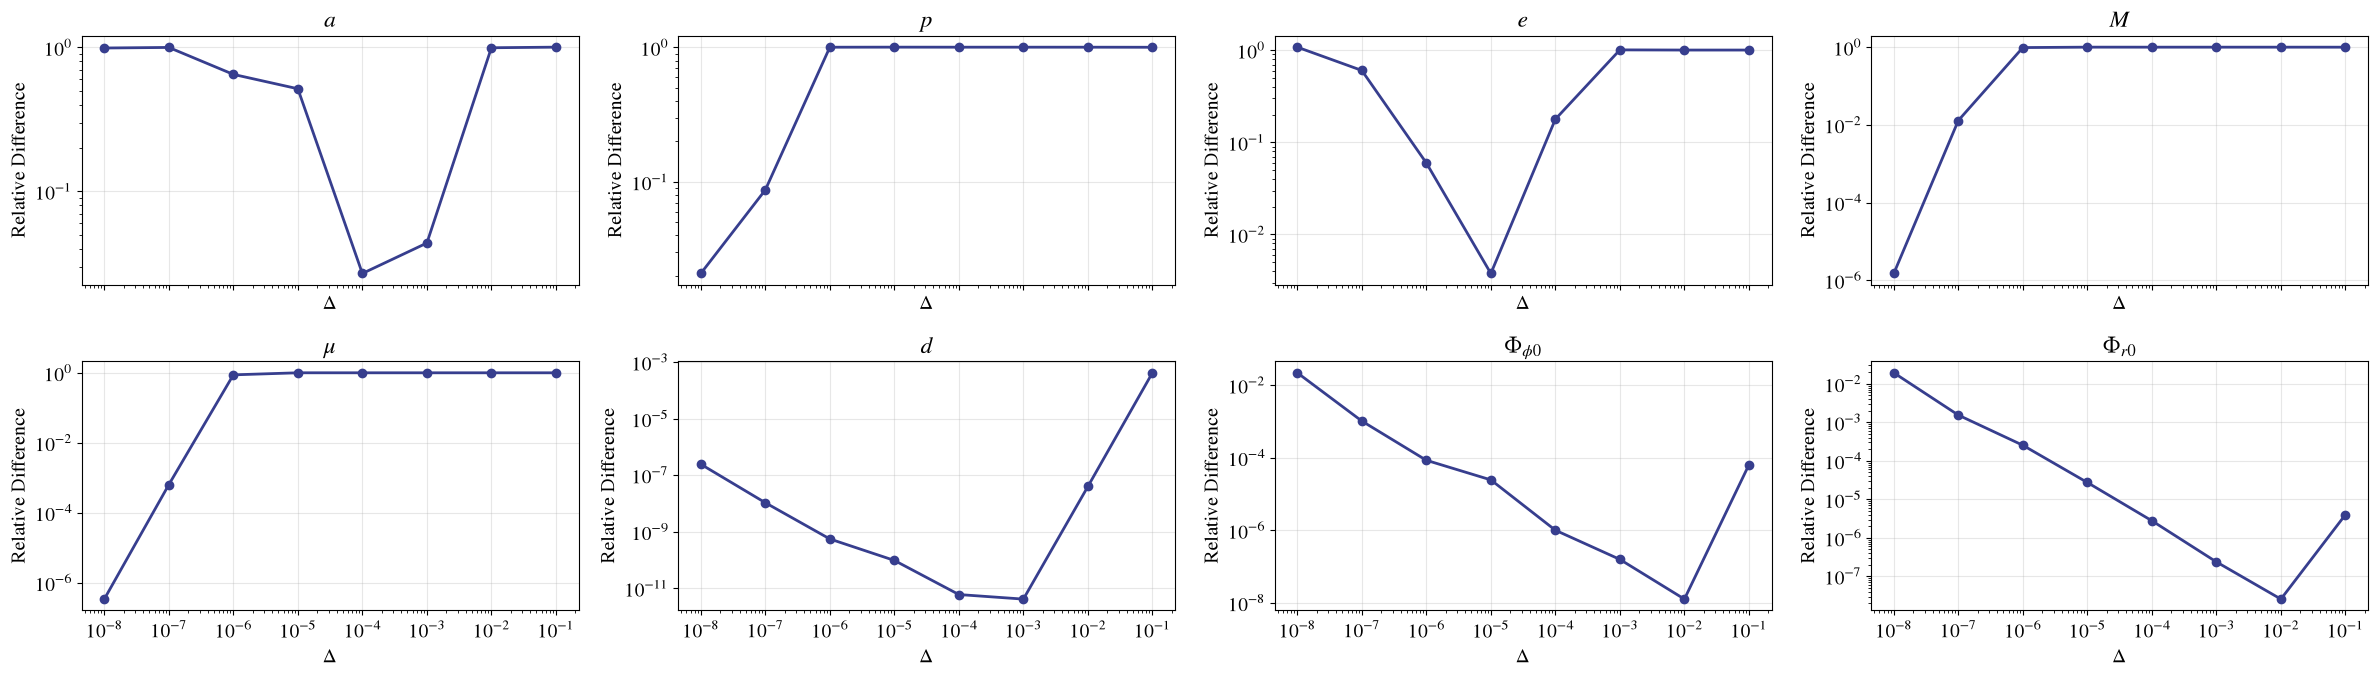

In [6]:
n_params = len(Parameters)
Parameters = [
    r"$a$",
    r"$p$",
    r"$e$",
    r"$M$",
    r"$\mu$",
    r"$d$",
    r"$\Phi_{\phi0}$",
    r"$\Phi_{r0}$"
]

# Arrange subplots in a grid
ncols = 4
nrows = int(np.ceil(n_params / ncols))

fig, axs = plt.subplots(nrows, ncols,
                        figsize=(6*ncols, 3*nrows+1),
                        sharex=True)

axs = axs.ravel()

# Use the midpoint of each pair of step sizes as the x-value
h_plot = steps[:-1]

print(h_plot)

for i, (name, errors) in enumerate(zip(Parameters, all_errors)):
    ax = axs[i]
    ax.plot(h_plot, errors, 'o-', lw=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(name)
    ax.set_xlabel(r"$\Delta$")
    ax.set_ylabel("Relative Difference")
    ax.grid(alpha=0.3)

# Remove unused axes
for ax in axs[n_params:]:
    fig.delaxes(ax)

fig.tight_layout()

plt.show()

[0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08]


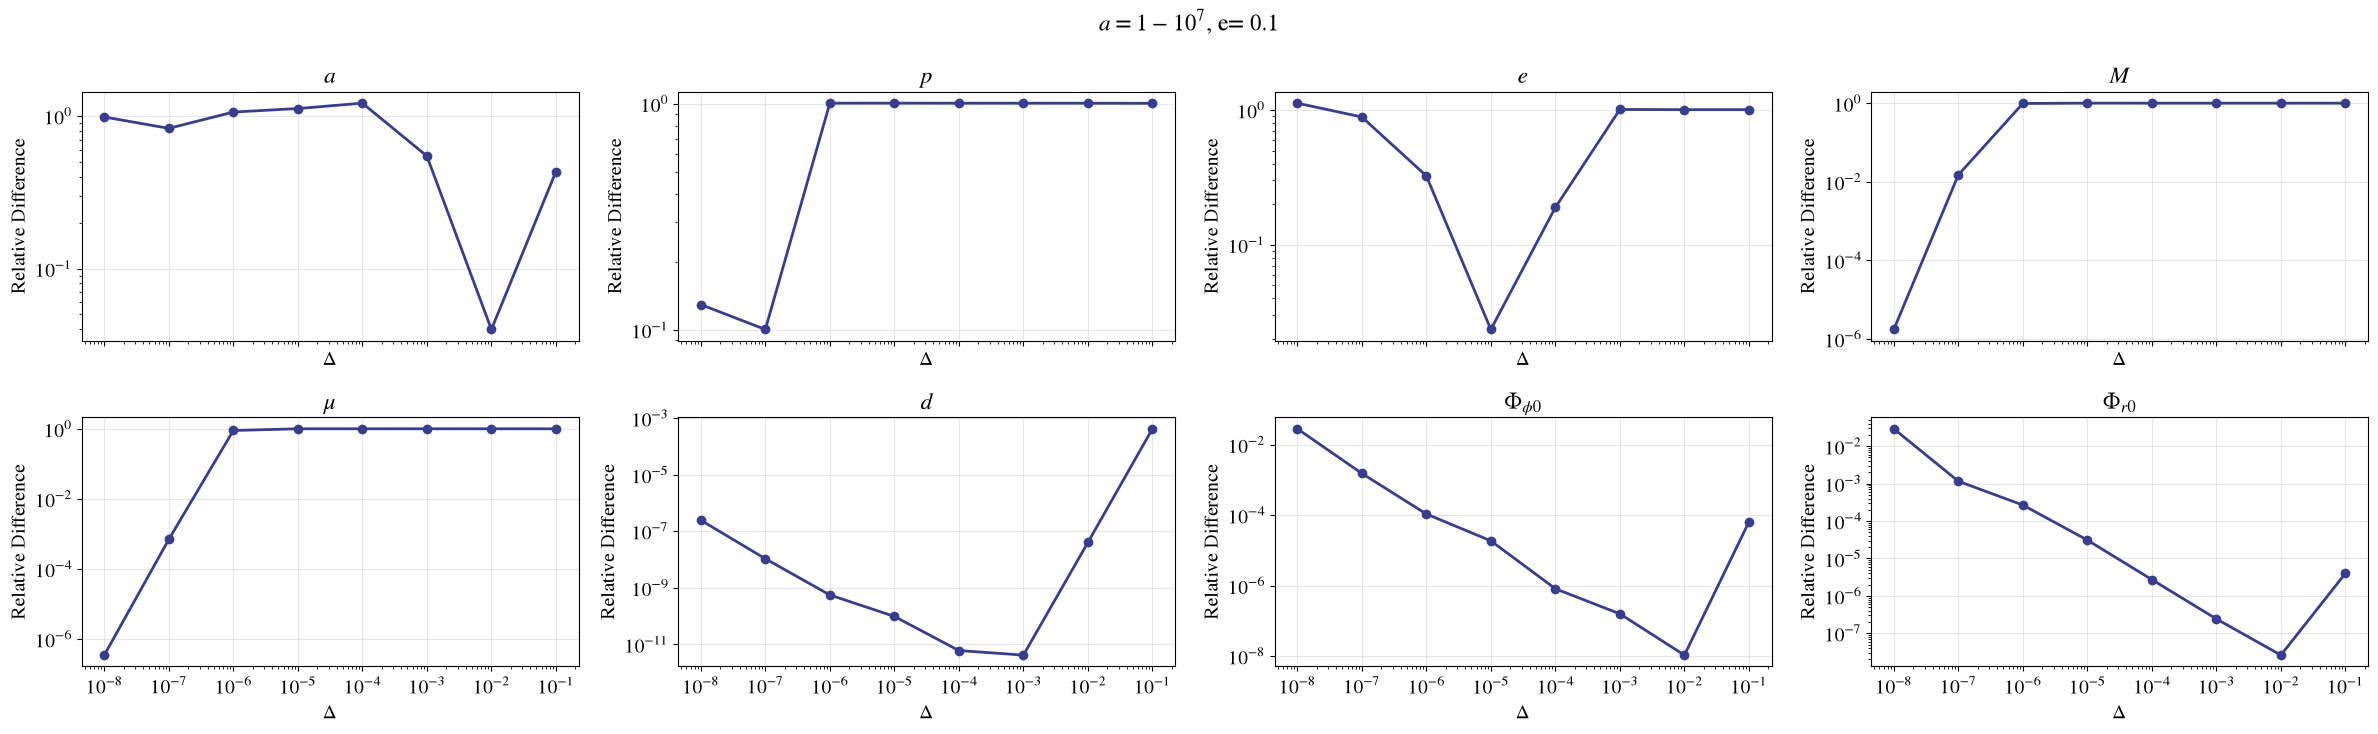

In [ ]:
n_params = len(Parameters)
Parameters = [
    r"$a$",
    r"$p$",
    r"$e$",
    r"$M$",
    r"$\mu$",
    r"$d$",
    r"$\Phi_{\phi0}$",
    r"$\Phi_{r0}$"
]

# Arrange subplots in a grid
ncols = 4
nrows = int(np.ceil(n_params / ncols))

fig, axs = plt.subplots(nrows, ncols,
                        figsize=(6*ncols, 3*nrows+1),
                        sharex=True)

axs = axs.ravel()

# Use the midpoint of each pair of step sizes as the x-value
h_plot = steps[:-1]

print(h_plot)

for i, (name, errors) in enumerate(zip(Parameters, all_errors)):
    ax = axs[i]
    ax.plot(h_plot, errors, 'o-', lw=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(name)
    ax.set_xlabel(r"$\Delta$")
    ax.set_ylabel("Relative Difference")
    ax.grid(alpha=0.3)

# Remove unused axes
for ax in axs[n_params:]:
    fig.delaxes(ax)

fig.tight_layout()

plt.suptitle(r"$a=1-10^{4}$, e= 0.1",y=1.05)

plt.show()
fig.savefig(f"Rel_diff_derivitaves_a=1-e-{4}_e=0.1.png", dpi=300, bbox_inches="tight")

In [51]:
np.size(all_errorsss)

12

(-3.0, 2.0)

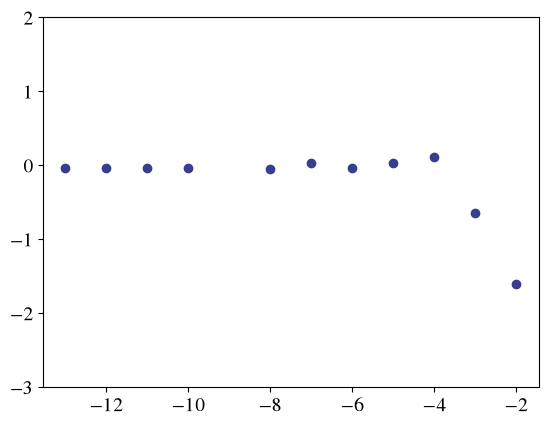

In [55]:
plt.scatter(np.log10(h_plot), np.log10(all_errorsss))
plt.ylim(-3,2)

In [118]:
dparams = []

for errors in all_errors:
    # Find index of minimum error
    min_index = np.argmin(errors)

    # Store corresponding step size
    dparams.append(steps[:-1][min_index])

In [120]:
dparams =[0.0005,
 1e-08,
 1e-05,
 1e-09,
 1e-08,
 0.0005,
 0.01,
 0.01]

In [126]:
Parameters = ["a","p","e","m1","m2","dist","Phi_phi0","Phi_r0"]
dparam = dparams[Parameters.index("Phi_r0")]
dparam

0.01

In [131]:
A = np.empty((len(Parameters), len(Parameters)), dtype=object)

for i in range(len(Parameters)):
    for j in range(len(Parameters)):
        A[i,j] = (Parameters[i], Parameters[j])


In [138]:
for name in A:
    print(name)
    print("____")

[('a', 'a') ('a', 'p') ('a', 'e') ('a', 'm1') ('a', 'm2') ('a', 'dist')
 ('a', 'Phi_phi0') ('a', 'Phi_r0')]
____
[('p', 'a') ('p', 'p') ('p', 'e') ('p', 'm1') ('p', 'm2') ('p', 'dist')
 ('p', 'Phi_phi0') ('p', 'Phi_r0')]
____
[('e', 'a') ('e', 'p') ('e', 'e') ('e', 'm1') ('e', 'm2') ('e', 'dist')
 ('e', 'Phi_phi0') ('e', 'Phi_r0')]
____
[('m1', 'a') ('m1', 'p') ('m1', 'e') ('m1', 'm1') ('m1', 'm2')
 ('m1', 'dist') ('m1', 'Phi_phi0') ('m1', 'Phi_r0')]
____
[('m2', 'a') ('m2', 'p') ('m2', 'e') ('m2', 'm1') ('m2', 'm2')
 ('m2', 'dist') ('m2', 'Phi_phi0') ('m2', 'Phi_r0')]
____
[('dist', 'a') ('dist', 'p') ('dist', 'e') ('dist', 'm1') ('dist', 'm2')
 ('dist', 'dist') ('dist', 'Phi_phi0') ('dist', 'Phi_r0')]
____
[('Phi_phi0', 'a') ('Phi_phi0', 'p') ('Phi_phi0', 'e') ('Phi_phi0', 'm1')
 ('Phi_phi0', 'm2') ('Phi_phi0', 'dist') ('Phi_phi0', 'Phi_phi0')
 ('Phi_phi0', 'Phi_r0')]
____
[('Phi_r0', 'a') ('Phi_r0', 'p') ('Phi_r0', 'e') ('Phi_r0', 'm1')
 ('Phi_r0', 'm2') ('Phi_r0', 'dist') ('Phi_r0'

In [13]:
Parameters = [
    "a",
    "p",
    "e",
    "m1",
    "m2",
    "dist",
    "Phi_phi0",
    "Phi_r0"
]


def compute_derivatives_fft(a, e0):

    derivs_fft = {}
    psds ={}
    freq = None

    for param in Parameters:

        # Compute waveform derivative
        t, derivative = stencil(param, a, e0)

        # Time spacing
        dt = t[1] - t[0]

        # FFT of derivative
        fft_deriv = (
            np.fft.fftshift(np.fft.fft(derivative))
            * dt
        )

        # Frequency array
        freq_full = np.fft.fftshift(
            np.fft.fftfreq(len(derivative), dt)
        )

        # Positive frequencies
        positive_frequency_mask = freq_full >= 0.0

        # Store only positive frequency part
        derivs_fft[param] = fft_deriv[positive_frequency_mask]

        psds[param] = get_sensitivity(freq_full[positive_frequency_mask]) / np.diff(freq_full)[0]

        # Store frequency array once
        if freq is None:
            freq = freq_full[positive_frequency_mask]

    return derivs_fft, freq, psds

In [ ]:
derivs_fft, freq, psds = compute_derivatives_fft(a, 0.001)


0it [00:00, ?it/s]


ValueError: setting an array element with a sequence.

In [174]:
A = np.zeros((len(Parameters), len(Parameters)))


for i, param_i in enumerate(Parameters):
    for j, param_j in enumerate(Parameters):

        A[i,j] = inner_product(
            derivs_fft[param_i],
            derivs_fft[param_j],
            psds[param_i]
        )



In [179]:
np.sqrt(np.linalg.inv(A)[0,0])

np.float64(4.721803869216547e-08)

Put it all together:

In [14]:
def Fisher_matrix(a,e):
    Parameters = [
    "a",
    "p",
    "e",
    "m1",
    "m2",
    "dist",
    "Phi_phi0",
    "Phi_r0"
]


    derivs_fft, freq, psds = compute_derivatives_fft(a, e)

    Gamma = np.zeros((len(Parameters), len(Parameters)))

    for i, param_i in enumerate(Parameters):
        for j, param_j in enumerate(Parameters):

            Gamma[i,j] = inner_product(
                derivs_fft[param_i],
                derivs_fft[param_j],
                psds[param_i]
            )
    return Gamma

In [24]:
A1 = Fisher_matrix(1-10**(-11),0.3999)


: 

In [19]:
import time

t1=time.time()

aaa=1-10**(-9)
eee= 0.3999

p0 = get_p_at_t(
    traj_module,
    1*0.99999,
    [1e6, 10,aaa,eee, 1.0],       
    index_of_p=3,               
    index_of_a=2,               
    index_of_e=4,               
    index_of_x=5,
    traj_kwargs={},
    xtol= 1e-5,                 
    rtol= 1e-5, 
    bounds=None,
)
t2=time.time()
print(f"found p0 in {round(t2-t1 ,2)} seconds")

found p0 in 21.84 seconds


In [20]:
p0

6.694138831762071

In [12]:
p0

6.71014486588964

In [10]:
p0

6.701144865889639

In [193]:
np.sqrt(np.linalg.inv(A1)[0,0]), np.sqrt(np.linalg.inv(A2)[0,0])

(np.float64(2.439756025872825e-07), np.float64(1.2245470617918352e-10))

In [15]:
a_vals = [1-1e-4,1-1e-5 , 1-1e-6,]#1-1e-7, 1-1e-8  , 1-1e-9 ]
e0=0.001


Mats = []
in_mats = []

for a_val in tqdm.tqdm(a_vals):
    Fisher_mat = Fisher_matrix(a_val,e0)

    in_fish = np.linalg.inv(Fisher_mat)

    Mats.append(Fisher_mat)
    in_mats.append(in_fish)



 33%|███▎      | 1/3 [00:46<01:32, 46.08s/it]


KeyboardInterrupt: 

Text(0.5, 1.0, 'e=0')

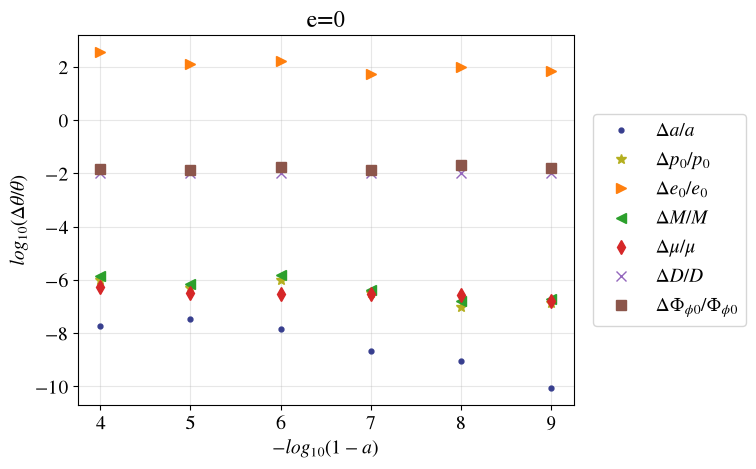

In [10]:
a_vals = [1-1e-4,1-1e-5 , 1-1e-6,1-1e-7, 1-1e-8, 1-1e-9 ]
a = np.asarray(a_vals)

param_vals = [a, 6.75 ,0.00000001, 1e6 , 10 , 1 , np.pi/3 , np.pi/3]

labels = [r"$\Delta a / a$", r"$\Delta p_0 / p_0$" , r"$\Delta e_0 / e_0$",
r"$\Delta M / M$", r"$\Delta \mu / \mu$",r"$\Delta D / D$", r"$\Delta \Phi_{\phi 0} / \Phi_{\phi 0}$"]#,
 #r"$\Delta \Phi_{r 0} / \Phi_{r 0}$"]

markers = [".","*",">","<","d","x","s"]


for i, label in enumerate(labels):
    Aii = [M[i, i] for M in in_mats]

    plt.plot(-np.log10(1-a) , np.log10( np.sqrt(Aii)/param_vals[i] ),markers[i],label = label, markersize=7,)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(alpha=0.3)
plt.xlabel(r"$-log_{10}(1-a)$")
plt.ylabel(r"$log_{10}(\Delta \theta / \theta)$")
plt.title("e=0")

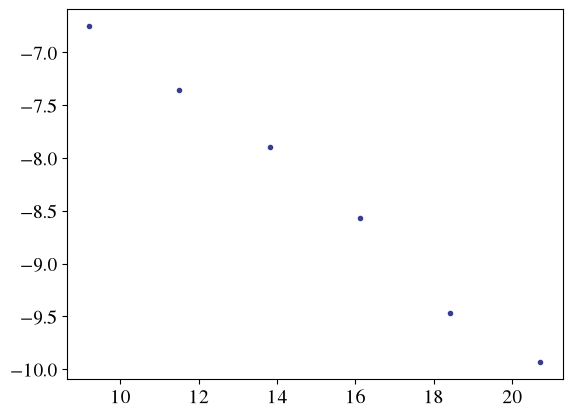

In [258]:

plt.plot(-np.log(1-a) , np.log10( np.sqrt(A00)/a ),".",label = r"$\Delta a / a$")

In [16]:
Fisher_mat = Fisher_matrix(0.9999,0.399)

NameError: name 'Fisher_matrix' is not defined

In [ ]:
e_vals = [0.001,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.399]
n_vals = [4,5,6,7,8,9,10]
for n in n_vals:


    a_val = a_val = 1- 10**(-n)


    Mats_e = []
    in_mats_e = []

    for e_val in tqdm.tqdm(e_vals):
        Fisher_mat = Fisher_matrix(a_val,e_val)

        in_fish = np.linalg.inv(Fisher_mat)

        Mats_e.append(Fisher_mat)
        in_mats_e.append(in_fish)

    np.save(f"Fisher_matrices_vary_e_n={n}.npy", in_mats_e)

  0%|          | 0/9 [00:00<?, ?it/s]

Text(0.5, 1.0, '$a=1-10^{-7}$')

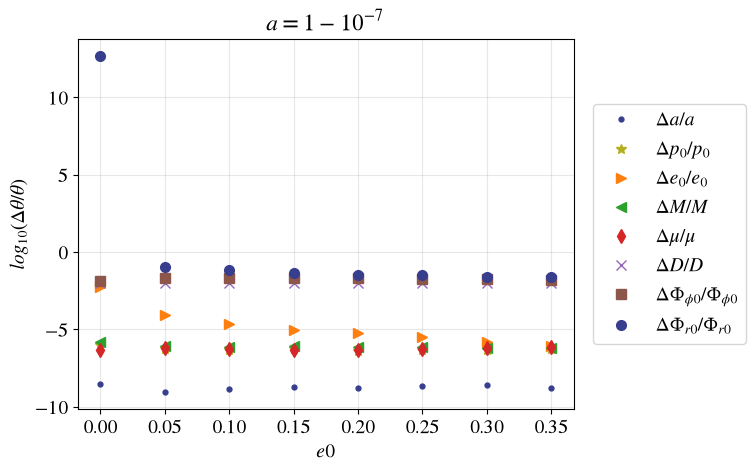

In [300]:
e_vals = [0.0000001,0.05,0.1,0.15,0.2,0.25,0.3,0.35]
ee = np.asarray(e_vals)

param_vals = [a_val, 6.75 ,ee, 1e6 , 10 , 1 , np.pi/3 , np.pi/3]

labels = [r"$\Delta a / a$", r"$\Delta p_0 / p_0$" , r"$\Delta e_0 / e_0$",
r"$\Delta M / M$", r"$\Delta \mu / \mu$",r"$\Delta D / D$", r"$\Delta \Phi_{\phi 0} / \Phi_{\phi 0}$",
 r"$\Delta \Phi_{r 0} / \Phi_{r 0}$"]

markers = [".","*",">","<","d","x","s","o"]


for i, label in enumerate(labels):
    Aii = [M[i, i] for M in in_mats_e]

    plt.plot(ee , np.log10( np.sqrt(Aii)/param_vals[i] ),markers[i],label = label, markersize=7,)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(alpha=0.3)
plt.xlabel(r"$e0$")
plt.ylabel(r"$log_{10}(\Delta \theta / \theta)$")
plt.title(fr"$a=1-10^{{-7}}$")

In [285]:
A00 = [M[0, 0] for M in in_mats_e]
np.size(A00)

8

In [287]:
np.size(ee)

8

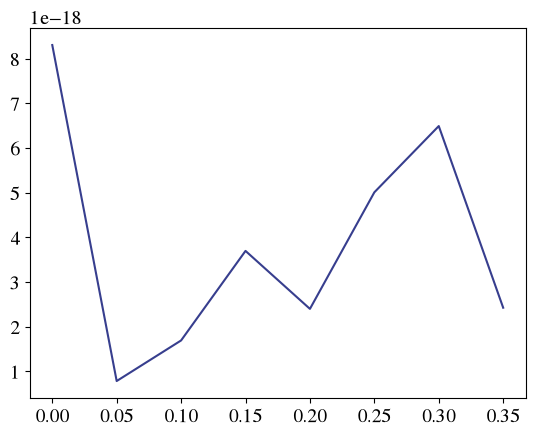

In [288]:
plt.plot(ee,A00)

In [298]:
in_mats_e[0]

array([[ 8.30693500e-18, -1.31695629e-14, -4.37380836e-19,
         2.83559525e-09, -3.44773173e-15,  2.72636560e-13,
         6.34120829e-12,  1.27895596e+01],
       [-1.31695629e-14,  4.29715185e-11,  2.04694457e-15,
        -9.32618940e-06,  2.29719342e-11, -7.38110082e-10,
        -3.02106790e-08, -5.70045273e+04],
       [-4.37380836e-19,  2.04694457e-15,  2.78092201e-19,
        -4.25508178e-10,  1.82445635e-15,  1.02111828e-13,
         8.49945972e-13, -4.96226892e+00],
       [ 2.83559525e-09, -9.32618940e-06, -4.25508178e-10,
         2.02930664e+00, -4.87398532e-06,  1.75466413e-04,
         7.45517744e-03,  1.22378146e+10],
       [-3.44773173e-15,  2.29719342e-11,  1.82445635e-15,
        -4.87398532e-06,  1.87070115e-11,  9.26403999e-11,
         2.87373537e-09, -3.99928736e+04],
       [ 2.72636560e-13, -7.38110082e-10,  1.02111828e-13,
         1.75466413e-04,  9.26403999e-11,  1.01122673e-04,
         2.38836388e-06,  2.11229174e+07],
       [ 6.34120829e-12, -3.021067

In [ ]:
Mamma = np.array(in_mats_e)      # shape (N, m, n)
n=7
#np.save(f"Fisher_matrices_vary_e_n={n}.npy", Mamma)

In [64]:
import numpy as np
import matplotlib.pyplot as plt
Mamma_reloaded = np.load("AFisher_matrices_vary_e_n=7.npy")

sdsd = Mamma_reloaded[0]
fdfd = Mamma_reloaded[3]

In [43]:
np.shape(Mamma_reloaded)

(8, 8, 8)

In [3]:
np.shape(in_mats_e)

NameError: name 'in_mats_e' is not defined

Text(0.5, 1.0, '$a=1-10^{-7}$')

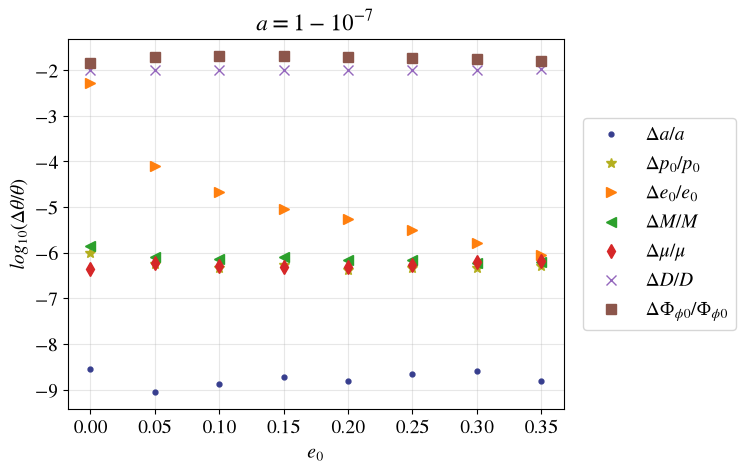

In [ ]:
e_vals = [0.001,0.05,0.1,0.15,0.2,0.25,0.3,0.35]
ee = np.asarray(e_vals)
a_val=1-1e-7

param_vals = [a_val, 6.75 ,ee, 1e6 , 10 , 1 , np.pi/3 , np.pi/3]

labels = [r"$\Delta a / a$", r"$\Delta p_0 / p_0$" , r"$\Delta e_0 / e_0$",
r"$\Delta M / M$", r"$\Delta \mu / \mu$",r"$\Delta D / D$", r"$\Delta \Phi_{\phi 0} / \Phi_{\phi 0}$"]#,
 #r"$\Delta \Phi_{r 0} / \Phi_{r 0}$"]

markers = [".","*",">","<","d","x","s","o"]


for i, label in enumerate(labels):
    Aii = [M[i, i] for M in Mamma_reloaded]

    plt.plot(ee , np.log10( np.sqrt(Aii)/param_vals[i] ),markers[i],label = label, markersize=7,)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(alpha=0.3)
plt.xlabel(r"$e_0$")
plt.ylabel(r"$log_{10}(\Delta \theta / \theta)$")
plt.title(fr"$a=1-10^{{-7}}$")

In [52]:
files = ["Fisher_matrices_vary_e_n=4.npy","Fisher_matrices_vary_e_n=5.npy",
"Fisher_matrices_vary_e_n=6.npy"]
ns = [4,5,6]
e_vals = [0.0000001,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.399]


for i, file in enumerate(files):
    matrices = np.load(file)

    n = ns[i]

    print(np.shape(matrices))

    for j, e_val in enumerate(e_vals):
        Ajj = [M[j, j] for M in matrices]

        print(Ajj)


(9, 8, 8)
[np.float64(3.385648557392269e-14), np.float64(2.2770774690537474e-14), np.float64(1.3418120984836121e-14), np.float64(1.0786369737781263e-14), np.float64(9.417997910398821e-15), np.float64(7.685183976118516e-15), np.float64(7.943618604717351e-15), np.float64(6.50301985636539e-15), np.float64(1.2033769239253959e-14)]
[np.float64(1.0777307116059526e-10), np.float64(1.2173809258357894e-10), np.float64(4.3830222963449375e-11), np.float64(2.7646868893885324e-11), np.float64(1.4175474952836375e-11), np.float64(5.712574995409643e-12), np.float64(8.965505751022296e-12), np.float64(9.505593120029869e-12), np.float64(5.6705030676906325e-12)]
[np.float64(2.344532087370582e-15), np.float64(3.0087664922836204e-11), np.float64(5.95992816304854e-12), np.float64(2.4829399282697354e-12), np.float64(1.2712852991694317e-12), np.float64(6.674064219066977e-13), np.float64(2.4409196444470424e-13), np.float64(8.395732145583253e-14), np.float64(2.4873848946433694e-14)]
[np.float64(5.029487352407883

IndexError: index 8 is out of bounds for axis 0 with size 8

In [45]:
labels = [r"$\Delta a / a$", r"$\Delta p_0 / p_0$" , r"$\Delta e_0 / e_0$",
r"$\Delta M / M$", r"$\Delta \mu / \mu$",r"$\Delta D / D$", r"$\Delta \Phi_{\phi 0} / \Phi_{\phi 0}$",
 r"$\Delta \Phi_{r 0} / \Phi_{r 0}$"]

In [70]:
eee = np.asarray(e_vals)
n_vals = [4,5,6]
nnn = np.asarray(n_vals)

EEE,NNN =np.meshgrid(eee,nnn)
DA = np.zeros_like(EEE)
DE = np.zeros_like(EEE)


for i, file in enumerate(files):
    matrices = np.load(file, allow_pickle=True)


    for j, e_val in enumerate(e_vals):
        A = matrices[j]        

        DA[i,j]+=A[0,0]
        DE[i,j]+=A[2,2]




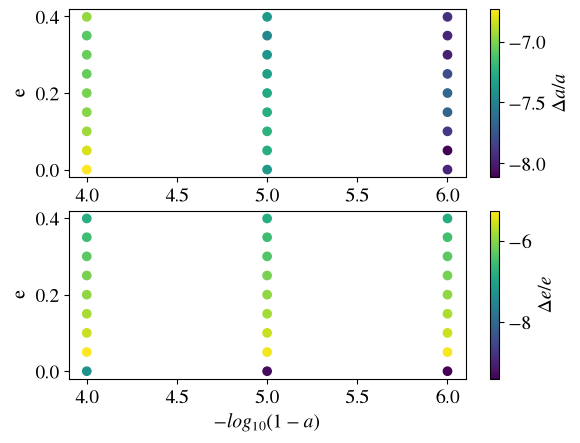

In [82]:
fig, axs = plt.subplots(2,1)

scatter1 = axs[0].scatter(NNN,EEE,c=np.log10(np.sqrt(DA)))
cbar1 = fig.colorbar(scatter1, ax=axs[0])
axs[0].set_xlabel(r"$-log_{10}(1-a)$")
axs[0].set_ylabel("e")
cbar1.set_label(r"$\Delta a/a$")


scatter2 = axs[1].scatter(NNN,EEE,c=np.log10(np.sqrt(DE)))
cbar2 = fig.colorbar(scatter2, ax=axs[1])
axs[1].set_xlabel(r"$-log_{10}(1-a)$")
axs[1].set_ylabel("e")
cbar2.set_label(r"$\Delta e/e$")


